# Mowing Detection: Prototype Standalone Application

**Author:** Florian Klaver

This notebook detects mowing events from a pair of Sentinel-2 images using a pre-trained classification model. It is recommended to use the Random Forest Model, but you can also try the SVM model. 
This is a simple prototype and works only on Sentinel-2 image data (no Radar) for reasons of data size and processing complexity.

**Required inputs:**
- A **before** Sentinel-2 GeoTIFF (image taken before the mowing event)
- An **after** Sentinel-2 GeoTIFF (image taken after the mowing event)
- The pre-trained model file (available in the [`standalone_models`](https://github.com/klaveflo/satellite-mowing-detection/tree/main/prototype_application/standalone_models) folder):
  - `s2_only_best_rf.joblib` - Random Forest, features: `ndii_diff`, `gndvi_diff`, `swir_diff`, `ndii_after`, `swir_after` 
  - `s2_only_best_svm.joblib` - SVM, same feature set
  - `s2_only_diff_rf.joblib` - Random Forest, features: `ndii_diff`, `gndvi_diff`, `swir_diff` **(recommended)**
  - `s2_only_diff_svm.joblib` - SVM, same feature set
- Path to folder for outputs

> If you don't already have relevant Sentinel-2 images on disk, simply download them from [Copernicus Browser](https://browser.dataspace.copernicus.eu).

<img src="../docs/images/Copernicus_browser_help.png" alt="What the Image download from Copernicus Browser should look like" width="50%">


**Optional inputs (all default to `None`, safe to leave unset):**
- A **study area** polygon (GeoPackage/Shapefile) to restrict analysis to a specific boundary
- A **grassland mask** (GeoPackage) to restrict analysis to grass-covered areas only
- A **ground truth** polygon file (GeoPackage) with known mowing events for accuracy evaluation

> **Usage:** Make sure to use the python envrironment (`Select Kernel`, top right corner) prepared with the `requirements.txt` from [GitHub](https://github.com/klaveflo/satellite-mowing-detection/tree/main) and run each cell from top to bottom.

---
## Step 1: Setup


In [28]:
# Standard libraries
from datetime import datetime
from pathlib import Path
import re

# Third-party libraries for geodata and machine learning
import geopandas as gpd
import joblib
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize as rio_rasterize
from rasterio.warp import Resampling, reproject
from scipy.ndimage import binary_closing, binary_opening
from scipy.ndimage import label as ndimage_label
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Plotting
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D as _Line2D
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt


try:
    from skimage.morphology import disk as skdisk
    _DISK_AVAILABLE = True
except ImportError:
    _DISK_AVAILABLE = False
    print("scikit-image not found, using square structuring element for morphological postprocessing.")

print("All packages imported successfully.")

All packages imported successfully.


If any import fails, install the missing package, then run cell above again  

---
## Step 2: Configuration

**Edit the paths below.** All optional inputs default to `None`, the pipeline runs correctly whether they are set or not.

In [29]:
# --- REQUIRED: input images and model ------------------------------------------------
# If you have downloaded Sentinel-2 images from the Copernicus Browser (one .tif per band),
# you can use the optional COPERNICUS_FOLDER_BEFORE and COPERNICUS_FOLDER_AFTER settings below
# instead of providing pre-combined GeoTIFFs.

# Sentinel-2 GeoTIFF taken BEFORE the mowing event
INPUT_BEFORE = Path("../data/Sentinel_CH/2019-06-19.tif")

# Sentinel-2 GeoTIFF taken AFTER the mowing event
INPUT_AFTER  = Path("../data/Sentinel_CH/2019-06-24.tif")

# Pre-trained model (.joblib) - choose one of the four available models:
#   s2_only_best_rf.joblib   - RF,  features: ndii_diff, gndvi_diff, swir_diff, ndii_after, swir_after (recommended)
#   s2_only_best_svm.joblib  - SVM, same feature set
#   s2_only_diff_rf.joblib   - RF,  features: ndii_diff, gndvi_diff, swir_diff
#   s2_only_diff_svm.joblib  - SVM, same feature set
MODEL_PATH   = Path("standalone_models/s2_only_diff_rf.joblib")

# Directory where output files will be saved
OUTPUT_DIR   = Path("data/results")


# --- OPTIONAL: study area boundary ------------------------------------------------
# Polygon(s) defining the area of interest. Only pixels inside are analysed.
# Set to None to use the full scene extent.

STUDY_AREA_PATH  = None   # e.g. Path("../data/study_area.gpkg")
STUDY_AREA_LAYER = None   # layer name inside GeoPackage; None = first layer / Shapefile


# --- OPTIONAL: grassland mask ------------------------------------------------
# GeoPackage with land-cover polygons. Only grassland pixels are analysed.
# Set GRASSLAND_MASK_PATH to None to skip.

GRASSLAND_MASK_PATH    = None   # e.g. Path("../data/amtliche_vermessung_zh/DM01AVZH24LV95.gpkg")
GRASSLAND_LAYER        = None   # e.g. "Bodenbedeckung_BoFlaeche_Area"
GRASSLAND_CLASS_COLUMN = None   # column to filter on, e.g. "Art_TXT"
GRASSLAND_CLASS_VALUE  = None   # value to keep,     e.g. "Wiesen und Weiden"


# --- OPTIONAL: ground truth comparison ------------------------------------------------
# Polygon file of known mowing events. Used to evaluate prediction accuracy.
# The polygons should represent areas mowed between the before and after dates.
# Set GROUND_TRUTH_PATH to None to skip evaluation.

GROUND_TRUTH_PATH         = "data/masks/ground_truth.gpkg"   # e.g. Path("../data/mowing_events_cleaned.gpkg")
GROUND_TRUTH_LAYER        = None   # layer name, e.g. "events_cleaned"; None = first layer
GROUND_TRUTH_DATE_COLUMN  = "mowing_date"   # date column for filtering events to the scene window
                                   # e.g. "date"; None = use ALL polygons in the file


# --- Optional: Convert Copernicus Browser download to required format ---
# Point to the unzipped folder from a Copernicus Browser L2A download.
# Set to None if you already have combined multi-band TIF files.
COPERNICUS_FOLDER_BEFORE = "data/s2_images/strickhof_2025-04-30"   # e.g., "downloads/S2A_20240610"
COPERNICUS_FOLDER_AFTER  = "data/s2_images/strickhof_2025-05-10"   # e.g., "downloads/S2A_20240615"


# --- ADVANCED: image band layout and postprocessing ------------------------------------------------
CLOUD_BAND         = 13   # 1-based band index for the cloud probability layer
CLOUD_THRESHOLD    = 30   # cloud probability threshold (%); pixels above are excluded
PP_DISK_RADIUS     = 1    # morphological structuring element radius (pixels)
PP_MIN_AREA_PIXELS = 4    # minimum mowing patch area to keep (pixels)
PP_MEDIAN_SIZE     = 3    # median pre-filter window (0 = disabled, 3/5/7 = window size)

# ------------------------------------------------
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Before image : {INPUT_BEFORE}")
print(f"After  image : {INPUT_AFTER}")
print(f"Model        : {MODEL_PATH}")
print(f"Output dir   : {OUTPUT_DIR}")
print()
print(f"Study area   : {STUDY_AREA_PATH or 'not set (full scene)'}")
print(f"Grassland    : {GRASSLAND_MASK_PATH or 'not set (all land cover)'}")
print(f"Ground truth : {GROUND_TRUTH_PATH or 'not set (no evaluation)'}")

Before image : ..\data\Sentinel_CH\2019-06-19.tif
After  image : ..\data\Sentinel_CH\2019-06-24.tif
Model        : standalone_models\s2_only_diff_rf.joblib
Output dir   : data\results

Study area   : not set (full scene)
Grassland    : not set (all land cover)
Ground truth : data/masks/ground_truth.gpkg


In [30]:
%pip install <package-name>

Note: you may need to restart the kernel to use updated packages.


Syntaxfehler.


---
## Data Preparation (Optional)

If you downloaded Sentinel-2 images from [Copernicus Browser](https://browser.dataspace.copernicus.eu), 
this cell converts them into the required format. 

**How to download:**
1. Go to Copernicus Browser and navigate to your area of interest
2. Find two cloud-free Sentinel-2 L2A scenes a few days apart
3. For each scene, click Download and select the full product or individual bands
4. Unzip the downloaded files into separate folders
5. Set the folder paths in the configuration above

If you already have combined multi-band GeoTIFF files, skip this cell.

In [31]:
def _convert_copernicus_folder(folder_path, label):
    """Convert a Copernicus Browser L2A download folder to a 6-band GeoTIFF."""
    folder = Path(folder_path)

    band_keywords = {
        'B02': '_B02_', 'B03': '_B03_', 'B04': '_B04_',
        'B08': '_B08_', 'B11': '_B11_', 'SCL': '_Scene_classification_map_',
    }

    # Gathers .tif, .tiff, .jp2, .jpg2 regardless of UPPERCASE or lowercase
    all_files = []
    for ext in ['*.tif', '*.tiff', '*.jp2', '*.TIF', '*.TIFF', '*.JP2']:
        all_files.extend(list(folder.rglob(ext)))


    found_bands = {}
    for band_key, keyword in band_keywords.items():
        matches = [f for f in all_files if keyword in f.name]
        if matches:
            found_bands[band_key] = matches[0]

    missing = [k for k in band_keywords if k not in found_bands]
    if missing:
        print(f"ERROR ({label}): Missing bands: {missing}")
        print(f"  Found: { {k: v.name for k, v in found_bands.items()} }")
        raise FileNotFoundError(f"Missing required bands in '{folder}': {missing}")

    # 1. Try matching the browser's dashed format: YYYY-MM-DD
    dashed_match = re.search(r'(\d{4}-\d{2}-\d{2})', found_bands['B02'].name)
    if dashed_match:
        date_str = dashed_match.group(1)
    else:
        # 2. Fallback to standard ESA format if user uses raw sci-hub data (YYYYMMDD)
        fallback_match = re.search(r'(\d{8})', found_bands['B02'].name)
        if fallback_match:
            raw_date = fallback_match.group(1)
            date_str = f"{raw_date[:4]}-{raw_date[4:6]}-{raw_date[6:8]}"
        else:
            raise ValueError(f"Could not extract date from filename: {found_bands['B02'].name}")

    # Read B02 as the 10m reference grid
    with rasterio.open(str(found_bands['B02'])) as ref_src:
        ref_crs       = ref_src.crs
        ref_transform = ref_src.transform
        ref_h, ref_w  = ref_src.height, ref_src.width
        b02 = ref_src.read(1).astype(np.float32)

    def _read_resampled(path, method):
        with rasterio.open(str(path)) as src:
            if src.height == ref_h and src.width == ref_w:
                return src.read(1).astype(np.float32)
            out = np.empty((ref_h, ref_w), dtype=np.float32)
            reproject(
                source=src.read(1).astype(np.float32),
                destination=out,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=method,
            )
            return out

    with rasterio.open(str(found_bands['B03'])) as s: b03 = s.read(1).astype(np.float32)
    with rasterio.open(str(found_bands['B04'])) as s: b04 = s.read(1).astype(np.float32)
    with rasterio.open(str(found_bands['B08'])) as s: b08 = s.read(1).astype(np.float32)
    b11 = _read_resampled(found_bands['B11'], Resampling.bilinear)
    scl = _read_resampled(found_bands['SCL'], Resampling.nearest)

    # SCL cloud classes: 8=cloud medium prob, 9=cloud high prob, 10=thin cirrus → 100%
    cloud_prob = np.where(np.isin(scl.astype(np.int16), [8, 9, 10]), 100, 0).astype(np.float32)

    # Stack: Band1=B02, Band2=B03, Band3=B04, Band4=B08, Band5=B11, Band6=cloud_prob
    stack = np.stack([b02, b03, b04, b08, b11, cloud_prob], axis=0)

    out_dir = Path("data/s2_images")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{date_str}.tif"

    with rasterio.open(str(out_path), 'w', driver='GTiff', dtype='float32',
                       width=ref_w, height=ref_h, count=6,
                       crs=ref_crs, transform=ref_transform, compress='lzw') as dst:
        dst.write(stack)

    print(f"Saved: data/s2_images/{date_str}.tif "
          f"(6 bands, {ref_w}x{ref_h} pixels, CRS: {ref_crs})")
    return out_path


if COPERNICUS_FOLDER_BEFORE is None and COPERNICUS_FOLDER_AFTER is None:
    print("No Copernicus download folders specified, expecting pre-combined TIF files.")
else:
    _cop_before_path = None
    _cop_after_path  = None

    if COPERNICUS_FOLDER_BEFORE is not None:
        _cop_before_path = _convert_copernicus_folder(COPERNICUS_FOLDER_BEFORE, 'before')
    if COPERNICUS_FOLDER_AFTER is not None:
        _cop_after_path  = _convert_copernicus_folder(COPERNICUS_FOLDER_AFTER, 'after')

    if _cop_before_path is not None:
        INPUT_BEFORE = _cop_before_path
    if _cop_after_path is not None:
        INPUT_AFTER = _cop_after_path

    print(f"\nUpdated image paths:")
    print(f"  Before: {INPUT_BEFORE}")
    print(f"  After : {INPUT_AFTER}")

    BAND_BLUE  = 1
    BAND_GREEN = 2
    BAND_RED   = 3
    BAND_NIR   = 4
    BAND_SWIR  = 5
    BAND_CLOUD = 6
    CLOUD_BAND = BAND_CLOUD
    print("Band configuration updated for 6-band Copernicus format.")

Saved: data/s2_images/2025-04-30.tif (6 bands, 213x324 pixels, CRS: EPSG:4326)
Saved: data/s2_images/2025-05-10.tif (6 bands, 213x324 pixels, CRS: EPSG:4326)

Updated image paths:
  Before: data\s2_images\2025-04-30.tif
  After : data\s2_images\2025-05-10.tif
Band configuration updated for 6-band Copernicus format.


---
## Step 3: Helper Functions

Defines all functions used by the pipeline. No changes needed here, just run the cell.

In [32]:
# --- Vegetation indices ------------------------------------------------------------------

def calculate_gndvi(nir, green):
    with np.errstate(divide='ignore', invalid='ignore'):
        r = (nir - green) / (nir + green)
    r[np.isinf(r)] = np.nan
    return r

def calculate_ndii(nir, swir):
    with np.errstate(divide='ignore', invalid='ignore'):
        r = (nir - swir) / (nir + swir)
    r[np.isinf(r)] = np.nan
    return r


# --- Postprocessing ---------------------------------------------------

def apply_median_filter(pred_map, size=3):
    """Median pre-filter to remove salt-and-pepper noise. Preserves nodata pixels."""
    from scipy.ndimage import median_filter as scipy_median_filter
    nodata_mask = (pred_map == -1)
    filtered = scipy_median_filter(
        np.where(nodata_mask, 0, pred_map).astype(np.float32), size=size)
    result = (filtered >= 0.5).astype(np.int8)
    result[nodata_mask] = -1
    return result

def apply_morphological_clean(pred_map, disk_radius=2, min_area_pixels=4):
    """
    Binary opening + closing then minimum-area filter.
    pred_map: 2-D int8 array with values {-1 (nodata), 0, 1}
    """
    nodata_mask = (pred_map == -1)
    binary = (pred_map == 1)
    struct = skdisk(disk_radius) if _DISK_AVAILABLE else np.ones(
        (2 * disk_radius + 1, 2 * disk_radius + 1), dtype=bool)
    opened = binary_opening(binary, structure=struct)
    closed = binary_closing(opened, structure=struct)
    labeled, n_comp = ndimage_label(closed)
    for cid in range(1, n_comp + 1):
        if np.sum(labeled == cid) < min_area_pixels:
            closed[labeled == cid] = False
    result = closed.astype(np.int8)
    result[nodata_mask] = -1
    return result


# --- Spatial masking from vector files -----------------------------------------------

def build_vector_mask(vector_path, layer, target_crs, transform, H, W,
                      filter_column=None, filter_value=None):
    """
    Read a vector file, optionally filter rows by a column value, reproject to
    target_crs, and rasterize to a flat boolean mask on the prediction grid.

    Returns a 1-D boolean array of length H*W.
    """
    gdf = gpd.read_file(str(vector_path), layer=layer)
    print(f"    Loaded {len(gdf)} features from '{vector_path.name}' (CRS: {gdf.crs})")
    gdf = gdf.to_crs(target_crs)
    if filter_column is not None and filter_value is not None:
        gdf = gdf[gdf[filter_column] == filter_value]
        print(f"    After filter '{filter_column}' == '{filter_value}': {len(gdf)} features")
    if len(gdf) == 0:
        print("    WARNING: no features remain after filtering, mask will be all-False.")
        return np.zeros(H * W, dtype=bool)
    mask_2d = rio_rasterize(
        shapes=((geom, 1) for geom in gdf.geometry if geom is not None),
        out_shape=(H, W),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=False,
    )
    return mask_2d.astype(bool).flatten()


# --- Feature computation -------------------------------------------------------------

def compute_features(before_path, after_path, cloud_band=13, cloud_threshold=30):
    """
    Load a before/after Sentinel-2 pair and compute the features required
    by the s2_only models. Also checks that both images share the same CRS.

    Two feature sets are supported (selected automatically from the loaded model):
      s2_only_best : ndii_diff, gndvi_diff, swir_diff, ndii_after, swir_after
      s2_only_diff : ndii_diff, gndvi_diff, swir_diff

    Band layout (1-based): 1=Blue, 2=Green, 3=Red, 4=NIR(B8), 5=SWIR(B11), 6=Cloud

    Returns
    -------
    feature_df : DataFrame with all model feature columns (NaN for invalid pixels)
    valid_mask : 1-D boolean array (H*W) - non-cloudy, non-NaN pixels
    cloud_mask : 1-D boolean array (H*W) - True where cloud probability exceeds threshold
    meta       : rasterio metadata dict (CRS, transform, shape)
    H, W       : scene height and width
    """
    with rasterio.open(str(before_path)) as src_b, \
         rasterio.open(str(after_path)) as src_a:

        if src_b.crs != src_a.crs:
            raise ValueError(
                f"CRS mismatch between before ({src_b.crs}) and after ({src_a.crs}) images. "
                "Reproject them to the same CRS before running this notebook."
            )

        meta = src_b.meta.copy()
        H, W = meta['height'], meta['width']

        # Read as float reflectance (Sentinel-2 DN / 10000)
        blue_b  = src_b.read(BAND_BLUE).astype(float) / 10000.0
        green_b = src_b.read(BAND_GREEN).astype(float) / 10000.0
        red_b   = src_b.read(BAND_RED).astype(float) / 10000.0
        nir_b   = src_b.read(BAND_NIR).astype(float) / 10000.0
        swir_b  = src_b.read(BAND_SWIR).astype(float) / 10000.0
        cloud_b = src_b.read(BAND_CLOUD).astype(float)

        blue_a  = src_a.read(BAND_BLUE).astype(float) / 10000.0
        green_a = src_a.read(BAND_GREEN).astype(float) / 10000.0
        red_a   = src_a.read(BAND_RED).astype(float) / 10000.0
        nir_a   = src_a.read(BAND_NIR).astype(float) / 10000.0
        swir_a  = src_a.read(BAND_SWIR).astype(float) / 10000.0
        cloud_a = src_a.read(BAND_CLOUD).astype(float)

    ndii_b  = calculate_ndii(nir_b,  swir_b)
    ndii_a  = calculate_ndii(nir_a,  swir_a)
    gndvi_b = calculate_gndvi(nir_b, green_b)
    gndvi_a = calculate_gndvi(nir_a, green_a)

    feature_df = pd.DataFrame({
        'ndii_diff':  (ndii_a  - ndii_b ).flatten(),
        'gndvi_diff': (gndvi_a - gndvi_b).flatten(),
        'swir_diff':  (swir_a  - swir_b ).flatten(),
        'ndii_after': ndii_a.flatten(),
        'swir_after': swir_a.flatten(),
    })

    cloud_mask = ((cloud_b > cloud_threshold) | (cloud_a > cloud_threshold)).flatten()
    nan_mask   = np.isnan(feature_df.values).any(axis=1)
    valid_mask = ~cloud_mask & ~nan_mask

    return feature_df, valid_mask, cloud_mask, meta, H, W


print("Helper functions defined.")

Helper functions defined.


---
## Step 4: Load Pre-trained Model

In [33]:
model_obj = joblib.load(MODEL_PATH)
model     = model_obj['model']      # sklearn Pipeline (StandardScaler + RandomForestClassifier)
features  = model_obj['features']   # list of feature names the model was trained on
threshold = model_obj['threshold']  # calibrated decision threshold

print(f"Model loaded : {MODEL_PATH.name}")
print(f"  Features ({len(features)}): {features}")
print(f"  Decision threshold: {threshold:.4f}")

Model loaded : s2_only_diff_rf.joblib
  Features (3): ['ndii_diff', 'gndvi_diff', 'swir_diff']
  Decision threshold: 0.8750


---
## Step 5: Load Images and Compute Features

Reads both Sentinel-2 images, verifies they share the same CRS, applies cloud masking, and computes vegetation index features.

In [34]:
print("Loading images and computing features...")

feature_df, valid_mask, cloud_mask, meta, H, W = compute_features(
    INPUT_BEFORE, INPUT_AFTER,
    cloud_band=CLOUD_BAND,
    cloud_threshold=CLOUD_THRESHOLD,
)

scene_crs       = meta['crs']
scene_transform = meta['transform']

# Compute pixel dimensions in metres — handles both projected (metres) and geographic (degrees) CRS
from pyproj import CRS as _ProjCRS, Geod as _Geod
_crs_obj = _ProjCRS.from_user_input(scene_crs)
if _crs_obj.is_geographic:
    _geod = _Geod(ellps='WGS84')
    _cx = scene_transform.c + scene_transform.a * W / 2
    _cy = scene_transform.f + scene_transform.e * H / 2
    _, _, _dx = _geod.inv(_cx, _cy, _cx + scene_transform.a, _cy)
    _, _, _dy = _geod.inv(_cx, _cy, _cx, _cy + scene_transform.e)
    pixel_size_x_m = abs(_dx)
    pixel_size_y_m = abs(_dy)
else:
    pixel_size_x_m = abs(scene_transform.a)
    pixel_size_y_m = abs(scene_transform.e)

pixel_area_m2 = pixel_size_x_m * pixel_size_y_m

n_total  = H * W
n_cloudy = int(cloud_mask.sum())

print(f"CRS             : {scene_crs}")
print(f"Pixel size      : {pixel_size_x_m:.1f} m x {pixel_size_y_m:.1f} m")
print(f"Scene dimensions: {H} x {W} = {n_total:,} pixels")
print(f"Cloudy / masked : {n_cloudy:,} pixels ({100 * n_cloudy / n_total:.1f}%)")
print(f"Cloud-free      : {int(valid_mask.sum()):,} pixels ({100 * valid_mask.mean():.1f}%)")

if valid_mask.sum() == 0:
    raise RuntimeError("No cloud-free pixels found. Check CLOUD_BAND and CLOUD_THRESHOLD.")

Loading images and computing features...
CRS             : EPSG:4326
Pixel size      : 6.8 m x 6.8 m
Scene dimensions: 324 x 213 = 69,012 pixels
Cloudy / masked : 0 pixels (0.0%)
Cloud-free      : 69,012 pixels (100.0%)


---
## Step 6: Apply Optional Spatial Masks

Restricts the analysis to the study area and/or grassland pixels.
If neither is set this cell does nothing and the full cloud-free scene is used.

In [35]:
# Start from the cloud-based mask produced in the previous step
analysis_mask = valid_mask.copy()

# --- Optional: study area boundary ------------------------------------------------
if STUDY_AREA_PATH is not None:
    print("Applying study area mask...")
    sa_mask = build_vector_mask(
        Path(STUDY_AREA_PATH), STUDY_AREA_LAYER,
        scene_crs, scene_transform, H, W,
    )
    n_before = int(analysis_mask.sum())
    analysis_mask = analysis_mask & sa_mask
    print(f"  Study area pixels        : {int(sa_mask.sum()):,}")
    print(f"  Valid pixels after filter: {int(analysis_mask.sum()):,}  "
          f"(removed {n_before - int(analysis_mask.sum()):,})")
else:
    print("Study area mask : not set (using full scene extent).")

# --- Optional: grassland mask ---------------------------------------------------------
if GRASSLAND_MASK_PATH is not None:
    print("Applying grassland mask...")
    grass_mask = build_vector_mask(
        Path(GRASSLAND_MASK_PATH), GRASSLAND_LAYER,
        scene_crs, scene_transform, H, W,
        filter_column=GRASSLAND_CLASS_COLUMN,
        filter_value=GRASSLAND_CLASS_VALUE,
    )
    n_before = int(analysis_mask.sum())
    analysis_mask = analysis_mask & grass_mask
    print(f"  Grassland pixels         : {int(grass_mask.sum()):,}")
    print(f"  Valid pixels after filter: {int(analysis_mask.sum()):,}  "
          f"(removed {n_before - int(analysis_mask.sum()):,})")
else:
    print("Grassland mask  : not set (predicting over all land cover types).")

# Update valid_mask so downstream cells pick up the spatial restrictions
valid_mask = analysis_mask
n_valid    = int(valid_mask.sum())

print(f"\nFinal valid pixels for prediction: {n_valid:,} "
      f"({100 * n_valid / n_total:.1f}% of scene)")

if n_valid == 0:
    raise RuntimeError("No valid pixels remain after spatial filtering. Check your mask inputs.")

Study area mask : not set (using full scene extent).
Grassland mask  : not set (predicting over all land cover types).

Final valid pixels for prediction: 69,012 (100.0% of scene)


---
## Visualization: Before / After RGB Comparison

Side-by-side true-colour view of the image pair
Optional overlays: cloud-masked pixels, AOI/grassland boundary, and ground truth boundaries.

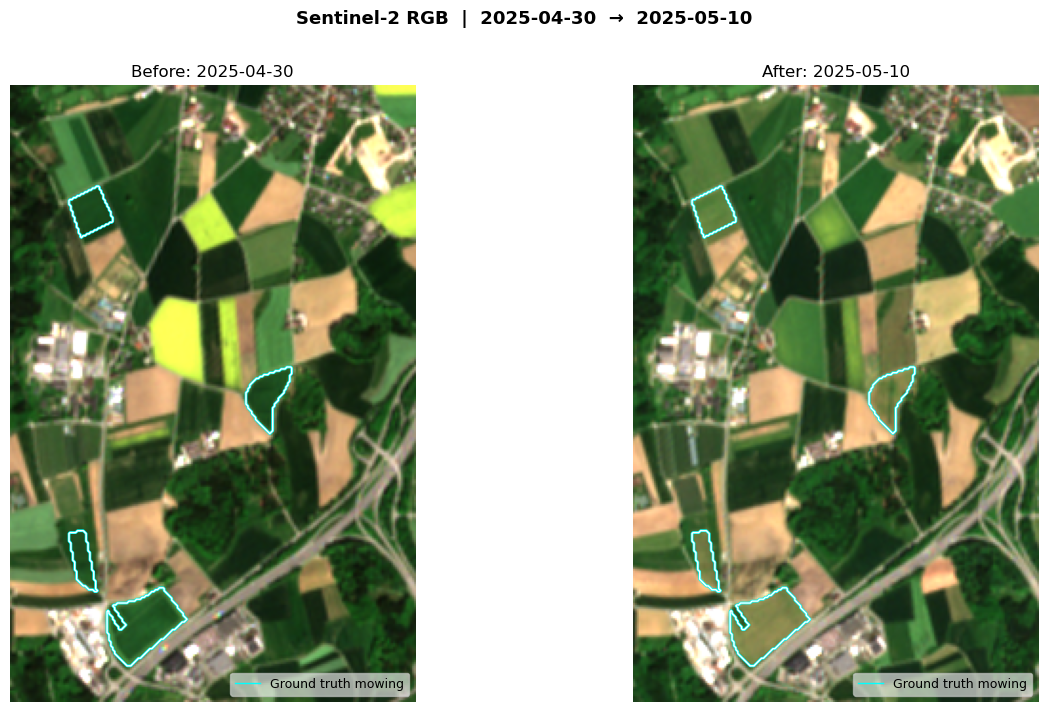

RGB comparison saved to: data\results\rgb_comparison_2025-04-30_2025-05-10.png


In [36]:
def _read_rgb(path):
    """Read R/G/B bands and normalize to 98th-percentile ceiling → float32 (H,W,3) in [0,1]."""
    with rasterio.open(str(path)) as src:
        rgb = src.read([BAND_RED, BAND_GREEN, BAND_BLUE]).astype(np.float32)
    rgb = np.moveaxis(rgb, 0, -1)
    p98 = np.percentile(rgb, 98)
    return np.clip(rgb, 0, max(p98, 1e-9)) / max(p98, 1e-9)

rgb_before = _read_rgb(INPUT_BEFORE)
rgb_after  = _read_rgb(INPUT_AFTER)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(rgb_before)
axes[0].set_title(f"Before: {INPUT_BEFORE.stem}", fontsize=12)
axes[0].axis('off')

axes[1].imshow(rgb_after)
axes[1].set_title(f"After: {INPUT_AFTER.stem}", fontsize=12)
axes[1].axis('off')

legend_handles = []

# AOI / grassland boundary - only if spatial masking was applied
has_spatial_restriction = (STUDY_AREA_PATH is not None) or (GRASSLAND_MASK_PATH is not None)
if has_spatial_restriction:
    aoi_2d = valid_mask.reshape(H, W).astype(float)
    for ax in axes:
        ax.contour(aoi_2d, levels=[0.5], colors='#CCCCCC', linewidths=0.8)
    legend_handles.append(
        _Line2D([0], [0], color='#CCCCCC', linewidth=0.8, label='AOI / grassland boundary'))

# Cloud-masked pixel overlay
cloud_2d = cloud_mask.reshape(H, W)
if cloud_2d.any():
    cloud_rgba = np.zeros((H, W, 4), dtype=np.uint8)
    cloud_rgba[cloud_2d] = [255, 255, 255, 110]
    for ax in axes:
        ax.imshow(cloud_rgba)
    legend_handles.append(
        mpatches.Patch(color=(1, 1, 1, 0.43), label='Cloud-masked pixels'))

# Ground truth boundaries — double-contour halo: black outer + white inner
if GROUND_TRUTH_PATH is not None:
    _gt_viz = gpd.read_file(str(GROUND_TRUTH_PATH), layer=GROUND_TRUTH_LAYER).to_crs(scene_crs)
    _gt_mask_viz = rio_rasterize(
        shapes=((geom, 1) for geom in _gt_viz.geometry if geom is not None),
        out_shape=(H, W), transform=scene_transform, fill=0, dtype='uint8',
    ).astype(float)
    for ax in axes:
        ax.contour(_gt_mask_viz, levels=[0.5], colors='cyan', linewidths=2.0)
        ax.contour(_gt_mask_viz, levels=[0.5], colors='white', linewidths=1.0)
    legend_handles.append(
        _Line2D([0], [0], color='cyan', linewidth=1.0,
                label='Ground truth mowing'))

if legend_handles:
    for ax in axes:
        ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.6)

fig.suptitle(f"Sentinel-2 RGB  |  {INPUT_BEFORE.stem}  →  {INPUT_AFTER.stem}",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = OUTPUT_DIR / f"rgb_comparison_{INPUT_BEFORE.stem}_{INPUT_AFTER.stem}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"RGB comparison saved to: {fig_path}")

---
## Step 7: Run Mowing Detection

Applies the model to every valid pixel, thresholds the probability output, and cleans the result with morphological postprocessing.

In [37]:
print("Running model prediction...")

proba_flat = np.full(H * W, np.nan, dtype=np.float32)
proba_flat[valid_mask] = model.predict_proba(feature_df.loc[valid_mask, features])[:, 1]

# -1 = nodata (outside valid mask)
pred_flat = np.full(H * W, -1, dtype=np.int8)
pred_flat[valid_mask] = (proba_flat[valid_mask] >= threshold).astype(np.int8)

pred_map_raw = pred_flat.reshape(H, W)

n_mowed_raw = int((pred_flat == 1).sum())
print(f"  Raw prediction           : {n_mowed_raw:,} mowed pixels "
      f"({100 * n_mowed_raw / n_valid:.2f}% of valid area)")

APPLY_POSTPROCESSING = True
if APPLY_POSTPROCESSING:
    print("Applying postprocessing...")
    pred_map_pp = pred_map_raw.copy()
    if PP_MEDIAN_SIZE > 0:
        pred_map_pp = apply_median_filter(pred_map_pp, size=PP_MEDIAN_SIZE)
    pred_map_pp = apply_morphological_clean(
        pred_map_pp, disk_radius=PP_DISK_RADIUS, min_area_pixels=PP_MIN_AREA_PIXELS)
else:
    pred_map_pp = pred_map_raw.copy()

n_mowed_pp = int((pred_map_pp == 1).sum())
print(f"  After postprocessing     : {n_mowed_pp:,} mowed pixels "
      f"({100 * n_mowed_pp / n_valid:.2f}% of valid area)")
print("Done.")

Running model prediction...
  Raw prediction           : 6,005 mowed pixels (8.70% of valid area)
Applying postprocessing...
  After postprocessing     : 5,820 mowed pixels (8.43% of valid area)
Done.


---
## Step 8: Visualise Prediction Map

Overlays detected mowing pixels (cyan) on the after-image RGB composite.

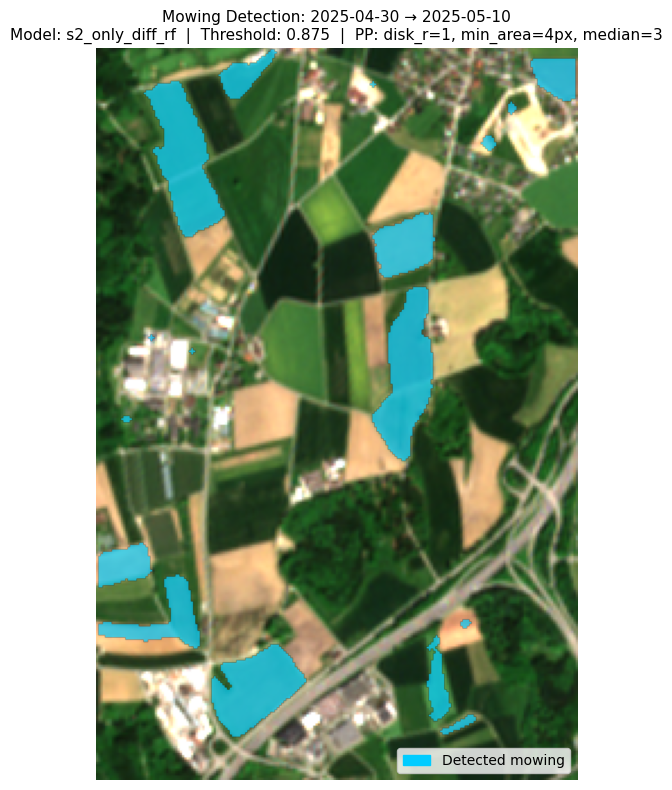

Detected mowing : 5,820 pixels
Saved to        : data\results\detection_2025-05-10_prediction.png


In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.imshow(rgb_after)

mowing_rgba = np.zeros((H, W, 4), dtype=np.uint8)
mowing_rgba[pred_map_pp == 1] = [0, 204, 255, 180]  # #00CCFF semi-transparent
ax.imshow(mowing_rgba)

ax.set_title(
    f"Mowing Detection: {INPUT_BEFORE.stem} → {INPUT_AFTER.stem}\n"
    f"Model: {MODEL_PATH.stem}  |  Threshold: {threshold:.3f}  |  "
    f"PP: disk_r={PP_DISK_RADIUS}, min_area={PP_MIN_AREA_PIXELS}px, median={PP_MEDIAN_SIZE}",
    fontsize=11)
ax.axis('off')

patch = mpatches.Patch(color='#00CCFF', label='Detected mowing')
ax.legend(handles=[patch], loc='lower right', fontsize=10)

plt.tight_layout()
fig_path = OUTPUT_DIR / f"detection_{INPUT_AFTER.stem}_prediction.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

has_aoi = (STUDY_AREA_PATH is not None) or (GRASSLAND_MASK_PATH is not None)
print(f"Detected mowing : {n_mowed_pp:,} pixels")
if has_aoi:
    print(f"AOI coverage    : {100 * n_mowed_pp / n_valid:.2f}% of valid AOI area classified as mowed")
print(f"Saved to        : {fig_path}")

---
## Step 9: Save Prediction as GeoTIFF

Pixel values: **1 = mowed**, **0 = not mowed**, **255 = no data (cloudy / outside mask)**.

In [39]:
output_path = OUTPUT_DIR / f"mowing_detection_{INPUT_AFTER.stem}.tif"

out_meta = meta.copy()
out_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255, 'compress': 'lzw'})

out_arr = pred_map_pp.astype(np.uint8)
out_arr[pred_map_pp == -1] = 255  # nodata

with rasterio.open(str(output_path), 'w', **out_meta) as dst:
    dst.write(out_arr, 1)
    dst.update_tags(
        BEFORE_IMAGE=INPUT_BEFORE.name,
        AFTER_IMAGE=INPUT_AFTER.name,
        MODEL=MODEL_PATH.name,
        THRESHOLD=str(round(threshold, 6)),
        POSTPROCESSING=f"morphological disk_r={PP_DISK_RADIUS} min_area={PP_MIN_AREA_PIXELS}",
        CREATED=datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    )

print(f"Prediction saved to: {output_path}")
print(f"  Encoding: 1=mowed, 0=not mowed, 255=no data")

Prediction saved to: data\results\mowing_detection_2025-05-10.tif
  Encoding: 1=mowed, 0=not mowed, 255=no data


---
## Step 10: Ground Truth Comparison (Optional)

Only runs when `GROUND_TRUTH_PATH` is set.  
Rasterizes the GT polygons to the prediction grid, computes precision / recall / F1, and shows a TP / FP / FN comparison map.

Ground truth evaluation...
  Loaded 9 features from 'ground_truth.gpkg' (CRS: EPSG:2056)
  Date filter 2025-04-30 < date <= 2025-05-10: 4 of 9 features kept

  GT mowed pixels : 2,038
  Pred mowed pixels: 5,820

  Precision : 0.348
  Recall    : 0.995
  F1 score  : 0.516

              precision    recall  f1-score   support

   not mowed       1.00      0.94      0.97     66974
       mowed       0.35      0.99      0.52      2038

    accuracy                           0.94     69012
   macro avg       0.67      0.97      0.74     69012
weighted avg       0.98      0.94      0.96     69012



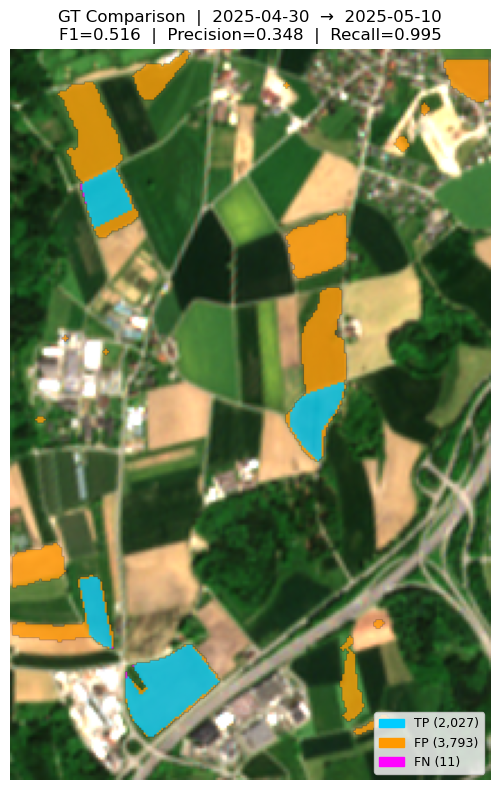

Evaluation map saved to: data\results\evaluation_2025-05-10.png


In [43]:
if GROUND_TRUTH_PATH is None:
    print("No ground truth provided, skipping evaluation.")
    print("Set GROUND_TRUTH_PATH in Step 2 to enable accuracy assessment.")
else:
    print("Ground truth evaluation...")

    # --- Load and optionally filter GT polygons ------------------------------------------------
    gt_gdf = gpd.read_file(str(GROUND_TRUTH_PATH), layer=GROUND_TRUTH_LAYER)
    print(f"  Loaded {len(gt_gdf)} features from '{Path(GROUND_TRUTH_PATH).name}' (CRS: {gt_gdf.crs})")
    gt_gdf = gt_gdf.to_crs(scene_crs)

    if GROUND_TRUTH_DATE_COLUMN is not None:
        # Parse scene window dates from filenames (expected format YYYY-MM-DD)
        try:
            date_before = datetime.strptime(INPUT_BEFORE.stem, '%Y-%m-%d').date()
            date_after  = datetime.strptime(INPUT_AFTER.stem,  '%Y-%m-%d').date()
            dates_ok = True
        except ValueError:
            print("  WARNING: could not parse dates from filenames, using all GT polygons without date filter.")
            dates_ok = False

        if dates_ok:
            gt_gdf[GROUND_TRUTH_DATE_COLUMN] = pd.to_datetime(
                gt_gdf[GROUND_TRUTH_DATE_COLUMN], errors='coerce').dt.date
            n_before_filter = len(gt_gdf)
            gt_gdf = gt_gdf[
                (gt_gdf[GROUND_TRUTH_DATE_COLUMN] > date_before) &
                (gt_gdf[GROUND_TRUTH_DATE_COLUMN] <= date_after)
            ]
            print(f"  Date filter {date_before} < date <= {date_after}: "
                  f"{len(gt_gdf)} of {n_before_filter} features kept")
    else:
        print("  GROUND_TRUTH_DATE_COLUMN not set, using all polygons in the file.")

    if len(gt_gdf) == 0:
        print("  No GT polygons remain after filtering, skipping evaluation.")
    else:
        # --- Rasterize GT to prediction grid ---------------------------------------------------
        gt_mask_2d = rio_rasterize(
            shapes=((geom, 1) for geom in gt_gdf.geometry if geom is not None),
            out_shape=(H, W),
            transform=scene_transform,
            fill=0,
            dtype='uint8',
            all_touched=False,
        )
        gt_flat = gt_mask_2d.flatten().astype(bool)

        # Evaluate only on valid (non-nodata) pixels
        eval_mask = valid_mask
        y_true = gt_flat[eval_mask].astype(int)
        y_pred = (pred_map_pp.flatten()[eval_mask] == 1).astype(int)

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        print(f"\n  GT mowed pixels : {int(gt_flat[eval_mask].sum()):,}")
        print(f"  Pred mowed pixels: {int(y_pred.sum()):,}")
        print()
        print(f"  Precision : {prec:.3f}")
        print(f"  Recall    : {rec:.3f}")
        print(f"  F1 score  : {f1:.3f}")
        print()
        print(classification_report(y_true, y_pred,
                                    target_names=['not mowed', 'mowed'],
                                    zero_division=0))

        # --- TP / FP / FN visualisation --------------------------------------------------------
        # 1=TP (cyan), 2=FP (orange), 3=FN (magenta); NaN=not evaluated
        category = np.full(H * W, np.nan, dtype=float)
        p = (pred_map_pp.flatten() == 1)
        g = gt_flat
        vm = valid_mask
        category[vm &  p[vm] &  g[vm]] = 1   # TP
        category[vm &  p[vm] & ~g[vm]] = 2   # FP
        category[vm & ~p[vm] &  g[vm]] = 3   # FN
        category_map = category.reshape(H, W)

        cmap_eval = ListedColormap(['#00CCFF', '#FF9900', '#FF00FF'])

        fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))

        ax2.imshow(rgb_after)
        ax2.imshow(category_map, cmap=cmap_eval, vmin=0.5, vmax=3.5, alpha=0.75)
        patches = [
            mpatches.Patch(color='#00CCFF', label=f'TP ({int((category==1).sum()):,})'),
            mpatches.Patch(color='#FF9900', label=f'FP ({int((category==2).sum()):,})'),
            mpatches.Patch(color='#FF00FF', label=f'FN ({int((category==3).sum()):,})'),
        ]
        ax2.legend(handles=patches, loc='lower right', fontsize=9)
        ax2.set_title(
            f"GT Comparison  |  {INPUT_BEFORE.stem}  →  {INPUT_AFTER.stem}\n"
            f"F1={f1:.3f}  |  Precision={prec:.3f}  |  Recall={rec:.3f}",
            fontsize=12)
        ax2.axis('off')

        plt.tight_layout()
        eval_fig_path = OUTPUT_DIR / f"evaluation_{INPUT_AFTER.stem}.png"
        plt.savefig(eval_fig_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Evaluation map saved to: {eval_fig_path}")

---
## Step 11: Summary

In [41]:
mowed_ha = n_mowed_pp * pixel_area_m2 / 10_000
valid_ha  = n_valid   * pixel_area_m2 / 10_000
scene_ha  = n_total   * pixel_area_m2 / 10_000

print("=" * 56)
print(" MOWING DETECTION SUMMARY")
print("=" * 56)
print(f" Before image     : {INPUT_BEFORE.name}")
print(f" After  image     : {INPUT_AFTER.name}")
print(f" Model            : {MODEL_PATH.name}")
print(f" Decision threshold: {threshold:.4f}")
print(f" CRS              : {scene_crs}")
print(f" Pixel size       : {pixel_area_m2:.0f} m2")
print("-" * 56)
print(f" Scene area       : {scene_ha:.1f} ha  ({n_total:,} px)")
print(f" Valid for analysis: {valid_ha:.1f} ha  ({n_valid:,} px)")
print(f" Detected mowing  : {mowed_ha:.2f} ha  ({n_mowed_pp:,} px)")
print(f" Coverage         : {100 * n_mowed_pp / n_valid:.2f}% of valid area")
print("-" * 56)
print(f" Study area mask  : {'yes, ' + str(STUDY_AREA_PATH) if STUDY_AREA_PATH else 'no'}")
print(f" Grassland mask   : {'yes, ' + str(GRASSLAND_MASK_PATH) if GRASSLAND_MASK_PATH else 'no'}")
print(f" Ground truth eval: {'yes, ' + str(GROUND_TRUTH_PATH) if GROUND_TRUTH_PATH else 'no'}")
print("-" * 56)
print(f" Output           : {output_path}")
print("=" * 56)

 MOWING DETECTION SUMMARY
 Before image     : 2025-04-30.tif
 After  image     : 2025-05-10.tif
 Model            : s2_only_diff_rf.joblib
 Decision threshold: 0.8750
 CRS              : EPSG:4326
 Pixel size       : 46 m2
--------------------------------------------------------
 Scene area       : 315.6 ha  (69,012 px)
 Valid for analysis: 315.6 ha  (69,012 px)
 Detected mowing  : 26.61 ha  (5,820 px)
 Coverage         : 8.43% of valid area
--------------------------------------------------------
 Study area mask  : no
 Grassland mask   : no
 Ground truth eval: yes, data/masks/ground_truth.gpkg
--------------------------------------------------------
 Output           : data\results\mowing_detection_2025-05-10.tif
